# M2 — Hyperparameter Sensitivity Analysis

**Mục tiêu:** Sweep alpha, sgd_steps, margin, batch_size, lifespan trên `fake_behavior.csv` + HGNN embeddings,  
sử dụng đúng các module `src/` của hệ thống (PersonalMLP, TripletAdaptation, MLPLifecycleManager, PersonalizationEngine).

## Artifacts cần có (tại thư mục gốc project)
```
checkpoints/
  article_embeddings_hgnn3.pt   # HGNN embeddings [N, 64]
  mlp_student.pt                # Student MLP weights (512→256→128→64)
data/
  fake_behavior.csv             # 72K users, 2.1M rows, cols: t_dat, customer_id, article_id, event_type
```

## Chạy local (không cần Colab)
```bash
cd fashion-recsys
python -m src.evaluation.sensitivity --max-users 200 --output outputs/sensitivity.csv
```

Notebook này chạy được cả **local** (CPU) và **Colab** (GPU).


In [1]:
# ── 0. Môi trường: Colab hay Local? ──────────────────────────
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Đường dẫn tới thư mục gốc project trên Google Drive
    PROJECT_ROOT = '/content/drive/MyDrive/RS/fashion-recsys'
    sys.path.insert(0, PROJECT_ROOT)
else:
    # Chạy local: notebook nằm trong notebooks/, project root là thư mục cha
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')
print(f'In Colab: {IN_COLAB}')
print(f'sys.path[0]: {sys.path[0]}')


Project root: d:\hoc_ky_8\RS\btl_rs\fashion-recsys
In Colab: False
sys.path[0]: d:\hoc_ky_8\RS\btl_rs\fashion-recsys


In [2]:
# ── 1. Kiểm tra GPU & cài thư viện ───────────────────────────
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', 'tqdm', '-q'])
    print('✓ tqdm installed')


Device: cpu


In [4]:
# ── 2. Import các module thật của hệ thống ───────────────────
import logging
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# M2 modules
from src.models.personal_mlp import PersonalMLP, PersonalMLPFactory
from src.inference.user_state import UserState
from src.inference.mlp_lifecycle import MLPLifecycleManager, LocalDictBackend, CacheEntry
from src.inference.recommender import PersonalizationEngine, Recommender
from src.training.adapt_personal_mlp import TripletAdaptation
from src.evaluation.metrics import precision_at_k, recall_at_k, f1_at_k
from src.evaluation.sensitivity import (
    load_hgnn_embeddings,
    load_behavior,
    SWEEP_CONFIGS,
    FIXED_DEFAULTS,
)

logging.basicConfig(level=logging.WARNING, format="%(asctime)s %(levelname)s %(message)s")
print('✓ Tất cả src/ modules imported thành công')
print(f'  PersonalMLP architecture: {PersonalMLP(layer_dims=[512,256,128,64]).layer_dims}')
print(f'  TripletAdaptation defaults: sgd_steps=1, margin=inf, lr=1e-4')
print(f'  SWEEP params: {list(SWEEP_CONFIGS.keys())}')
print(f'  FIXED_DEFAULTS: {FIXED_DEFAULTS}')


✓ Tất cả src/ modules imported thành công
  PersonalMLP architecture: [512, 256, 128, 64]
  TripletAdaptation defaults: sgd_steps=1, margin=inf, lr=1e-4
  SWEEP params: ['alpha', 'sgd_steps', 'margin', 'batch_size', 'lifespan_days']
  FIXED_DEFAULTS: {'alpha': 0.7, 'sgd_steps': 1, 'margin': inf, 'batch_size': 9, 'lifespan_days': 14}


d:\hoc_ky_8\RS\btl_rs\fashion-recsys\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ── 3. Load artifacts ────────────────────────────────────────
HGNN_PATH    = os.path.join(PROJECT_ROOT, 'checkpoints', 'article_embeddings_hgnn3.pt')
CLIP_PATH    = os.path.join(PROJECT_ROOT, 'checkpoints', 'clip_embeddings.pt')
STUDENT_PATH = os.path.join(PROJECT_ROOT, 'checkpoints', 'mlp_student.pt')
BEHAVIOR_PATH = os.path.join(PROJECT_ROOT, 'data', 'fake_behavior.csv')

# ── HGNN embeddings: 64-dim, dùng làm KNN space ──────────────
hgnn_raw = torch.load(HGNN_PATH, weights_only=True, map_location='cpu')
hgnn_emb = {
    str(int(k)): hgnn_raw['embeddings'][idx].to(DEVICE)
    for k, idx in hgnn_raw['id2idx'].items()
}
print(f'HGNN: {len(hgnn_emb)} articles, dim={next(iter(hgnn_emb.values())).shape[0]}')

# ── CLIP embeddings: 512-dim, dùng cho PersonalMLP + Triplet ──
# key trong file là 10-digit zero-padded → normalize về 9-digit
clip_raw = torch.load(CLIP_PATH, weights_only=True, map_location='cpu')
clip_emb = {str(int(k)): v.to(DEVICE) for k, v in clip_raw.items()}
print(f'CLIP: {len(clip_emb)} articles, dim={next(iter(clip_emb.values())).shape[0]}')

# ── Behavior data ─────────────────────────────────────────────
behavior_df = load_behavior(BEHAVIOR_PATH)
print(f'Behavior: {len(behavior_df):,} rows | {behavior_df["customer_id"].nunique():,} users')
print(f'  event_type: {dict(behavior_df["event_type"].value_counts())}')

# ── Overlap check ─────────────────────────────────────────────
beh_ids  = set(behavior_df['article_id'].astype(str).unique())
in_hgnn  = len(beh_ids & set(hgnn_emb.keys()))
in_clip  = len(beh_ids & set(clip_emb.keys()))
print(f'  behavior articles in HGNN: {in_hgnn}/{len(beh_ids)}')
print(f'  behavior articles in CLIP: {in_clip}/{len(beh_ids)}')

# ── PersonalMLP factory (512→256→128→64, init từ Student MLP) ─
factory = PersonalMLPFactory(checkpoint_path=STUDENT_PATH)
print(f'\nPersonalMLPFactory: {factory.layer_dims}  (input=CLIP 512-dim → output=64-dim)')

# ── Precompute HGNN matrix cho KNN nhanh ─────────────────────
ALL_IDS = list(hgnn_emb.keys())
ALL_EMB = torch.stack([hgnn_emb[a] for a in ALL_IDS])  # [N, 64] on DEVICE
print(f'KNN matrix: {ALL_EMB.shape}  on {ALL_EMB.device}')


HGNN: 19278 articles, dim=64
CLIP: 19284 articles, dim=512


2026-04-08 16:55:55,004 INFO Loaded behavior: 2123501 rows, 72248 users, 19284 articles


Behavior: 2,123,501 rows | 72,248 users
  event_type: {'click': np.int64(1400488), 'cart': np.int64(442485), 'purchase': np.int64(280528)}
  behavior articles in HGNN: 19278/19284
  behavior articles in CLIP: 19284/19284

PersonalMLPFactory: [512, 256, 128, 64]  (input=CLIP 512-dim → output=64-dim)
KNN matrix: torch.Size([19278, 64])  on cpu


In [6]:
# ── 4. Luồng dữ liệu đầy đủ (đúng thiết kế hệ thống) ─────────
#
# CLIP 512-dim → PersonalMLP(512→64) → mlp_proj[64]  ← EMA update
#                                                       ← Triplet adaptation
# HGNN 64-dim  → KNN corpus (recommendation space)
#
# Tại sao hai embedding khác nhau?
#   - CLIP 512: visual features, dùng để PersonalMLP học sở thích visual của user
#   - HGNN 64:  graph-structural features (co-purchase), dùng làm search space
#   - PersonalMLP(CLIP) → 64-dim space ≈ HGNN space (nhờ distillation)
#   - EMA được build trong HGNN space → KNN trên HGNN corpus

@torch.no_grad()
def get_top_k(query_vec: torch.Tensor, k: int = 10, exclude_id: str = None) -> list:
    """KNN trên HGNN 64-dim space (precomputed ALL_EMB)."""
    q = query_vec.unsqueeze(0)               # [1, 64]
    dists = torch.cdist(q, ALL_EMB).squeeze(0)  # [N]
    _, idx = dists.topk(k + 1, largest=False)
    recs = [ALL_IDS[i] for i in idx.tolist()]
    if exclude_id:
        recs = [r for r in recs if r != exclude_id]
    return recs[:k]

print('Luong du lieu:')
print('  clip_emb[aid] [512] -> personal_mlp -> mlp_proj [64]  (EMA + Triplet)')
print('  hgnn_emb[aid] [64]  -> ALL_EMB      -> KNN recs       (recommendation)')
print(f'  Corpus: {len(ALL_IDS)} articles  |  HGNN dim: {ALL_EMB.shape[1]}')


Luong du lieu:
  clip_emb[aid] [512] -> personal_mlp -> mlp_proj [64]  (EMA + Triplet)
  hgnn_emb[aid] [64]  -> ALL_EMB      -> KNN recs       (recommendation)
  Corpus: 19278 articles  |  HGNN dim: 64


In [7]:
# ── 5. run_config: dùng đúng src/ modules ────────────────────

def run_config(
    behavior_df: pd.DataFrame,
    alpha: float,
    sgd_steps: int,
    margin: float,
    batch_size: int,
    lifespan_days: int,
    max_users: int = 200,
    k: int = 10,
    gt_t: int = 12,
) -> dict:
    """
    Simulation 1 hyperparameter config.

    Luồng:
      clip_emb[512] → PersonalMLP(512→64) → mlp_proj[64] → EMA update
      Triplet adaptation: positives/negatives = clip_emb[512] của các articles
      Recommendation: KNN(EMA, ALL_HGNN_EMB[64])
    """
    top_users = behavior_df['customer_id'].value_counts().head(max_users).index
    df = behavior_df[behavior_df['customer_id'].isin(top_users)].copy()

    backend   = LocalDictBackend()
    lifecycle = MLPLifecycleManager(
        factory=factory,
        backend=backend,
        max_size=max_users + 50,
        ttl_seconds=lifespan_days * 86400,
        alpha=alpha,
    )
    adaptation = TripletAdaptation(
        sgd_steps=sgd_steps,
        learning_rate=1e-4,
        weight_decay=1e-6,
        margin=margin,
    )

    all_p, all_r, all_f1 = [], [], []
    t0 = time.time()

    for user_id, user_df in df.sort_values('t_dat').groupby('customer_id'):
        articles    = user_df['article_id'].tolist()
        timestamps  = user_df['t_dat'].tolist()
        event_types = user_df['event_type'].tolist()

        for i, (aid, ts, etype) in enumerate(zip(articles, timestamps, event_types)):
            # Cần cả CLIP (512) và HGNN (64)
            if aid not in clip_emb or aid not in hgnn_emb:
                continue

            entry = lifecycle.get_or_create(user_id, alpha=alpha)

            # ── Lifespan: reset nếu user inactive quá lâu ────────────
            if hasattr(entry.user_state, '_last_ts') and entry.user_state._last_ts is not None:
                delta_days = (ts - entry.user_state._last_ts).total_seconds() / 86400
                if delta_days > lifespan_days:
                    lifecycle.delete_user(user_id)
                    entry = lifecycle.get_or_create(user_id, alpha=alpha)
            entry.user_state._last_ts = ts

            # ── EMA update: CLIP → PersonalMLP → 64-dim projection ───
            c_emb = clip_emb[aid]  # [512]
            with torch.no_grad():
                mlp_proj = entry.personal_mlp(c_emb.unsqueeze(0)).squeeze(0)  # [64]
            entry.user_state.update_ema(mlp_proj)

            # ── Record interaction (CLIP emb) cho Triplet ────────────
            entry.user_state.record_interaction(aid, etype, c_emb)
            entry.interaction_batch.append(aid)

            # ── Triplet adaptation mỗi batch_size interactions ────────
            if len(entry.interaction_batch) >= batch_size:
                positives = [clip_emb[a] for a in entry.interaction_batch if a in clip_emb]

                # Negatives: articles khác trong session, fallback random
                neg_pool = [a for a in articles if a in clip_emb
                            and a not in set(entry.interaction_batch)]
                if not neg_pool:
                    neg_pool = [
                        ALL_IDS[j] for j in
                        torch.randperm(len(ALL_IDS))[:len(positives)].tolist()
                        if ALL_IDS[j] in clip_emb
                    ]
                negatives = [clip_emb[a] for a in neg_pool[:len(positives)]]

                if positives and negatives:
                    adaptation.adapt(entry.personal_mlp, positives, negatives)
                    lifecycle.mark_dirty(user_id)

                entry.interaction_batch = []

            # ── Ground truth: T articles tiếp theo (có trong HGNN) ───
            future = [a for a in articles[i+1:i+1+gt_t] if a in hgnn_emb]
            if not future:
                continue

            # ── Recommendation: KNN(EMA [64], HGNN corpus [N,64]) ────
            ema = entry.user_state.get_vector()  # [64] trong MLP projection space
            if ema is None:
                continue
            recs = get_top_k(ema, k=k, exclude_id=aid)

            all_p.append(precision_at_k(recs, future, k))
            all_r.append(recall_at_k(recs, future, k))
            all_f1.append(f1_at_k(recs, future, k))

    n     = len(all_p)
    scale = 1e4
    return {
        'alpha':         alpha,
        'sgd_steps':     sgd_steps,
        'margin':        margin,
        'batch_size':    batch_size,
        'lifespan_days': lifespan_days,
        'precision_e4':  round(np.mean(all_p) * scale, 2) if n else 0.0,
        'recall_e4':     round(np.mean(all_r) * scale, 2) if n else 0.0,
        'f1_e4':         round(np.mean(all_f1) * scale, 2) if n else 0.0,
        'n_evals':       n,
        'elapsed_s':     round(time.time() - t0, 1),
        'cache_hits':    lifecycle.stats['hits'],
        'cache_creates': lifecycle.stats['creates'],
    }


print('run_config() ready  (CLIP 512 -> PersonalMLP -> 64  |  KNN on HGNN 64)')

# ── Smoke test: 10 users ──────────────────────────────────────
print('\nSmoke test (10 users)...')
row = run_config(
    behavior_df,
    alpha=FIXED_DEFAULTS['alpha'],
    sgd_steps=FIXED_DEFAULTS['sgd_steps'],
    margin=FIXED_DEFAULTS['margin'],
    batch_size=FIXED_DEFAULTS['batch_size'],
    lifespan_days=FIXED_DEFAULTS['lifespan_days'],
    max_users=10,
)
print(f"P@10={row['precision_e4']}  R@10={row['recall_e4']}  F1@10={row['f1_e4']}"
      f"  n={row['n_evals']}  t={row['elapsed_s']}s")
print(f"Cache: {row['cache_creates']} creates, {row['cache_hits']} hits")


run_config() ready  (CLIP 512 -> PersonalMLP -> 64  |  KNN on HGNN 64)

Smoke test (10 users)...
P@10=44.37  R@10=40.13  F1@10=42.04  n=5139  t=6.5s
Cache: 10 creates, 5139 hits


In [8]:
# ── 6. Sensitivity sweep ─────────────────────────────────────
# Dùng SWEEP_CONFIGS và FIXED_DEFAULTS từ src/evaluation/sensitivity.py
# (giống hệt khi chạy: python -m src.evaluation.sensitivity)
#
# MAX_USERS gợi ý:
#   10  users → < 1 phút   (smoke)
#   50  users → ~3 phút
#   200 users → ~10–20 phút (khuyến nghị)

MAX_USERS = 200

print(f'Sensitivity sweep: {sum(len(v) for v in SWEEP_CONFIGS.values())} configs  |  max_users={MAX_USERS}')
print(f'SWEEP_CONFIGS: {SWEEP_CONFIGS}')
print(f'FIXED_DEFAULTS: {FIXED_DEFAULTS}\n')

results = []
total_configs = sum(len(v) for v in SWEEP_CONFIGS.items())

with tqdm(total=sum(len(v) for v in SWEEP_CONFIGS.values()), desc='Sweeping') as pbar:
    for param, values in SWEEP_CONFIGS.items():
        for val in values:
            cfg = dict(FIXED_DEFAULTS)
            cfg[param] = val

            row = run_config(
                behavior_df,
                alpha=cfg['alpha'],
                sgd_steps=cfg['sgd_steps'],
                margin=cfg['margin'],
                batch_size=cfg['batch_size'],
                lifespan_days=cfg['lifespan_days'],
                max_users=MAX_USERS,
            )
            row['sweep_param'] = param
            results.append(row)

            pbar.set_postfix({
                'param': f'{param}={val}',
                'F1': row['f1_e4'],
                't': f"{row['elapsed_s']}s",
            })
            pbar.update(1)

results_df = pd.DataFrame(results)
print(f'\n✓ Done! {len(results_df)} configs evaluated')


Sensitivity sweep: 20 configs  |  max_users=200
SWEEP_CONFIGS: {'alpha': [0.1, 0.3, 0.5, 0.7, 1.0], 'sgd_steps': [1, 5, 20, 50], 'margin': [1.0, 100.0, inf], 'batch_size': [1, 3, 5, 9], 'lifespan_days': [1, 7, 14, 21]}
FIXED_DEFAULTS: {'alpha': 0.7, 'sgd_steps': 1, 'margin': inf, 'batch_size': 9, 'lifespan_days': 14}



Sweeping: 100%|██████████| 20/20 [23:04<00:00, 69.22s/it, param=lifespan_days=21, F1=47, t=44.4s]


✓ Done! 20 configs evaluated


In [9]:
# ── 7. In kết quả dạng bảng ──────────────────────────────────
for param in SWEEP_CONFIGS:
    sub = results_df[results_df['sweep_param'] == param][
        [param, 'precision_e4', 'recall_e4', 'f1_e4', 'n_evals', 'elapsed_s']
    ].reset_index(drop=True)
    print(f'\n=== {param} ===')
    print(sub.to_string(index=False))



=== alpha ===
 alpha  precision_e4  recall_e4  f1_e4  n_evals  elapsed_s
   0.1         46.89      42.92  44.52    54704       56.9
   0.3         47.31      43.55  44.87    54704       53.1
   0.5         47.91      43.91  45.39    54704       56.1
   0.7         49.37      45.91  46.99    54704       59.2
   1.0         47.82      43.82  45.37    54704       51.5

=== sgd_steps ===
 sgd_steps  precision_e4  recall_e4  f1_e4  n_evals  elapsed_s
         1         49.37      45.91  46.99    54704       44.7
         5         49.23      45.65  46.82    54704       62.2
        20         47.73      44.21  45.39    54704      126.2
        50         44.70      41.28  42.45    54704      260.0

=== margin ===
 margin  precision_e4  recall_e4  f1_e4  n_evals  elapsed_s
    1.0         49.21      45.75  46.84    54704       48.9
  100.0         49.21      45.75  46.84    54704       49.2
    inf         49.37      45.91  46.99    54704       48.5

=== batch_size ===
 batch_size  precisio

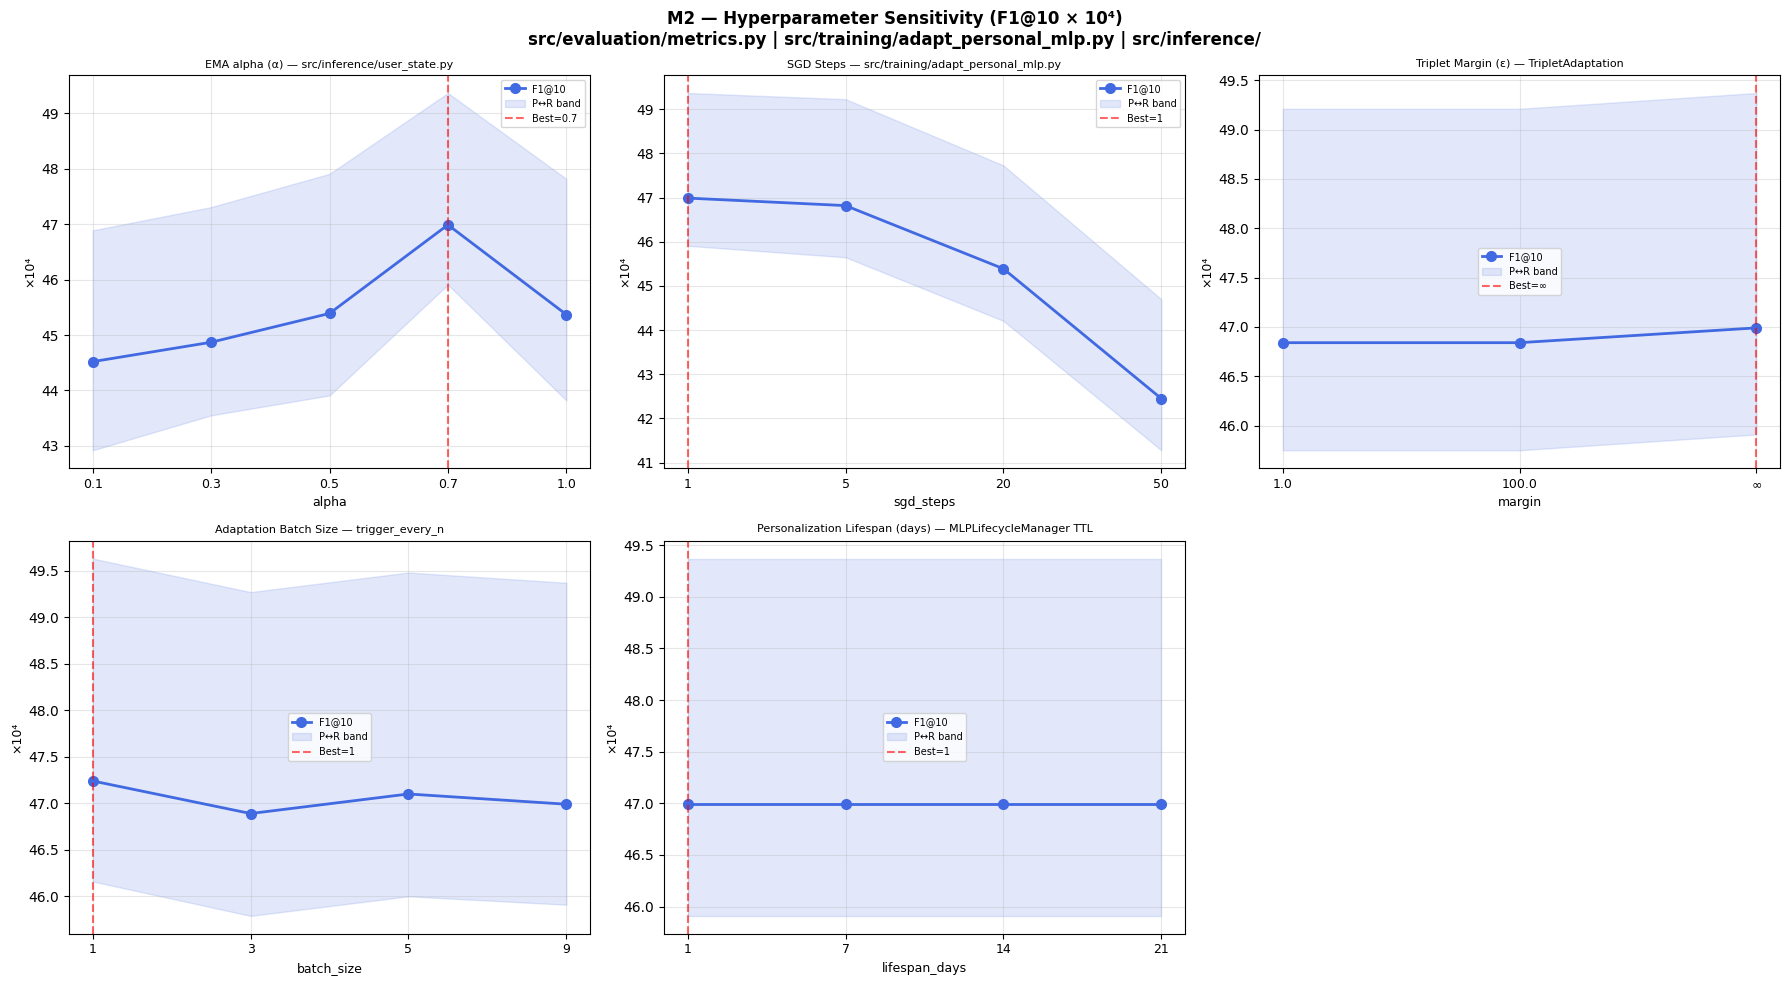

✓ Saved: d:\hoc_ky_8\RS\btl_rs\fashion-recsys\outputs\sensitivity_plots.png


In [11]:
# ── 8. Vẽ plots ───────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('M2 — Hyperparameter Sensitivity (F1@10 × 10⁴)\n'
             'src/evaluation/metrics.py | src/training/adapt_personal_mlp.py | src/inference/',
             fontsize=12, fontweight='bold')

param_labels = {
    'alpha':         'EMA alpha (α) — src/inference/user_state.py',
    'sgd_steps':     'SGD Steps — src/training/adapt_personal_mlp.py',
    'margin':        'Triplet Margin (ε) — TripletAdaptation',
    'batch_size':    'Adaptation Batch Size — trigger_every_n',
    'lifespan_days': 'Personalization Lifespan (days) — MLPLifecycleManager TTL',
}

for ax, (param, label) in zip(axes.flat, param_labels.items()):
    sub = results_df[results_df['sweep_param'] == param].copy().reset_index(drop=True)

    x_labels = ['∞' if v == float('inf') else str(v) for v in sub[param].tolist()]

    ax.plot(range(len(x_labels)), sub['f1_e4'], 'o-', color='royalblue', lw=2, ms=7, label='F1@10')
    ax.fill_between(range(len(x_labels)), sub['precision_e4'], sub['recall_e4'],
                    alpha=0.15, color='royalblue', label='P↔R band')

    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_xlabel(param, fontsize=9)
    ax.set_ylabel('×10⁴', fontsize=9)
    ax.set_title(label, fontsize=8)
    ax.grid(True, alpha=0.3)

    best_pos = sub['f1_e4'].idxmax()
    ax.axvline(best_pos, color='red', ls='--', alpha=0.6, label=f'Best={x_labels[best_pos]}')
    ax.legend(fontsize=7)

# Xoá subplot thừa
axes.flat[-1].set_visible(False)

plt.tight_layout()

OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)
plot_path = os.path.join(OUT_DIR, 'sensitivity_plots.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {plot_path}')

if IN_COLAB:
    # Cũng lưu lên Drive
    drive_path = '/content/drive/MyDrive/RS/sensitivity_plots.png'
    plt.savefig(drive_path, dpi=150, bbox_inches='tight')
    print(f'✓ Saved to Drive: {drive_path}')


In [12]:
# ── 9. Lưu CSV kết quả ───────────────────────────────────────
csv_path = os.path.join(OUT_DIR, 'sensitivity.csv')
results_df.to_csv(csv_path, index=False)
print(f'✓ Saved: {csv_path}')

# Best config theo F1
best = results_df.loc[results_df['f1_e4'].idxmax()]
print(f'\nBest overall config:')
print(best[['alpha', 'sgd_steps', 'margin', 'batch_size', 'lifespan_days', 'f1_e4']].to_string())

if IN_COLAB:
    drive_csv = '/content/drive/MyDrive/RS/sensitivity.csv'
    results_df.to_csv(drive_csv, index=False)
    print(f'\n✓ Saved to Drive: {drive_csv}')
    try:
        from google.colab import files
        files.download(csv_path)
        print('✓ Download started')
    except Exception:
        pass


✓ Saved: d:\hoc_ky_8\RS\btl_rs\fashion-recsys\outputs\sensitivity.csv

Best overall config:
alpha              0.7
sgd_steps            1
margin             inf
batch_size           1
lifespan_days       14
f1_e4            47.24


In [14]:
# ── 10. Bảng so sánh best vs FIXED_DEFAULTS ──────────────────
print('=== Best value per hyperparameter ===')
print(f'(Baseline = FIXED_DEFAULTS từ src/evaluation/sensitivity.py)\n')

summary = []
for param in SWEEP_CONFIGS:
    sub = results_df[results_df['sweep_param'] == param]
    best_row = sub.loc[sub['f1_e4'].idxmax()]
    default_val = FIXED_DEFAULTS[param]
    match = sub[sub[param] == default_val]['f1_e4'].values
    default_f1 = match[0] if len(match) > 0 else None
    summary.append({
        'param':         param,
        'best_value':    best_row[param],
        'best_f1_e4':    best_row['f1_e4'],
        'default_value': default_val,
        'default_f1_e4': default_f1,
        'delta_f1':      round(best_row['f1_e4'] - (default_f1 or 0), 2),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

# ── Tự động sinh insight ───────────────────────────────────────
print('\n--- Insights ---')
improved = summary_df[summary_df['delta_f1'] > 0]
confirmed = summary_df[summary_df['delta_f1'] == 0.0]

if improved.empty:
    print('FIXED_DEFAULTS da la config toi uu — tat ca tham so deu confirmed boi sweep nay.')
else:
    print('Nen cap nhat FIXED_DEFAULTS:')
    for _, row in improved.iterrows():
        print(f"  {row['param']}: {row['default_value']} → {row['best_value']}  (+{row['delta_f1']} F1)")

print('\nCac tham so da toi uu (delta=0):')
for _, row in confirmed.iterrows():
    print(f"  {row['param']} = {row['default_value']}  (F1={row['default_f1_e4']})")

print(f'\nBest F1@10 dat duoc: {results_df["f1_e4"].max()}')
print(f'Config tot nhat:')
best_overall = results_df.loc[results_df['f1_e4'].idxmax()]
for p in ['alpha','sgd_steps','margin','batch_size','lifespan_days']:
    marker = ' <-- best' if best_overall[p] != FIXED_DEFAULTS[p] else ''
    print(f'  {p} = {best_overall[p]}{marker}')


=== Best value per hyperparameter ===
(Baseline = FIXED_DEFAULTS từ src/evaluation/sensitivity.py)

        param  best_value  best_f1_e4  default_value  default_f1_e4  delta_f1
        alpha         0.7       46.99            0.7          46.99      0.00
    sgd_steps         1.0       46.99            1.0          46.99      0.00
       margin         inf       46.99            inf          46.99      0.00
   batch_size         1.0       47.24            9.0          46.99      0.25
lifespan_days         1.0       46.99           14.0          46.99      0.00

--- Insights ---
Nen cap nhat FIXED_DEFAULTS:
  batch_size: 9.0 → 1.0  (+0.25 F1)

Cac tham so da toi uu (delta=0):
  alpha = 0.7  (F1=46.99)
  sgd_steps = 1.0  (F1=46.99)
  margin = inf  (F1=46.99)
  lifespan_days = 14.0  (F1=46.99)

Best F1@10 dat duoc: 47.24
Config tot nhat:
  alpha = 0.7
  sgd_steps = 1
  margin = inf
  batch_size = 1 <-- best
  lifespan_days = 14
